# Programmation Orientée Objet et Hooks

In [1]:
# https://docs.python.org/3/library/collections.abc.html
from collections.abc import Sized, Collection, Iterable, Sequence

import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
from geometry import Polygon

## Builtins repr, str

In [2]:
data = np.random.normal(10.0, 2.5, 1_000_000)
print(data) # calls str()
data # calls repr()

[14.79135195 10.01184239 10.61792717 ... 14.18090318  8.08084513
  8.82078928]


array([14.79135195, 10.01184239, 10.61792717, ..., 14.18090318,
        8.08084513,  8.82078928], shape=(1000000,))

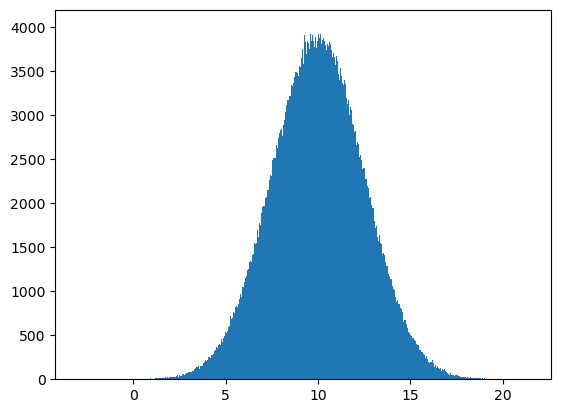

In [3]:
_ = plt.hist(data, bins=1_000)

In [4]:
data

array([14.79135195, 10.01184239, 10.61792717, ..., 14.18090318,
        8.08084513,  8.82078928], shape=(1000000,))

## Builtin len
Implemented by `__len__`

In [5]:
city_name = 'Toulouse'
cities = ['Toulouse', 'Bordeaux', 'Narbonne', 'Pau']
number = 123
triangle = Polygon([
    (12.5, 7.25), 
    (12.5, 10.25), 
    (16.5, 7.25)
])

In [6]:
print(len(data)) # calls ndarray.__len__
print(len(city_name)) # calls str.__len__
# print(len(number)) # TypeError: object of type 'int' has no len()
print(len(triangle))

1000000
8
3


## Classes abstraites collections.abc

In [7]:
assert hasattr(triangle, '__len__')

assert isinstance(triangle, Sized)
for obj in city_name, data, triangle:
    assert isinstance(obj, Sized)

assert not isinstance(number, Sized)

In [8]:


assert isinstance(cities, object)
assert isinstance(cities, list)
assert isinstance(cities, Sized)
assert isinstance(cities, Sequence)
assert isinstance(cities, Collection)
assert isinstance(cities, Iterable)

In [9]:
print(len(cities))
print(cities[0], cities[-1])
print('Toulouse' in cities)
for city in cities:
    print(city)

4
Toulouse Pau
True
Toulouse
Bordeaux
Narbonne
Pau


In [10]:
assert isinstance(city_name, Sequence)
assert not isinstance({'a': 1}, Sequence)
assert not isinstance({1, 2, 3}, Sequence)

# Iterable / Iterator

In [11]:
# str is Iterable => calls iter() => str.__iter__()
for letter in city_name:
    print(letter, end=' ')

T o u l o u s e 

In [12]:
for city in cities: # calls list.__iter()
    print(city)

Toulouse
Bordeaux
Narbonne
Pau


In [13]:
numbers = {12, 34, 26, 18}
numbers.add(18)
numbers.add(25)
assert 18 in numbers
assert 7 not in numbers
assert not isinstance(numbers, Sequence)
assert isinstance(numbers, Iterable)
for nb in numbers: # calls set.__iter__()
    print(nb)

34
12
18
25
26


In [14]:
city_d = {
    'name': 'Toulouse',
    'population': 500_000,
    'dept': '31'
}
city_d

{'name': 'Toulouse', 'population': 500000, 'dept': '31'}

In [15]:
# dict iteration => keys
for info_name in city_d:
    print(info_name)

name
population
dept


In [16]:
for info_name in city_d.keys():
    print(info_name)

name
population
dept


In [17]:
for info_value in city_d.values():
    print(info_value)

Toulouse
500000
31


In [18]:
for info_name, info_value in city_d.items():
    print(info_name, info_value, sep=' = ')

name = Toulouse
population = 500000
dept = 31


In [19]:
it = iter(cities)
it

In [20]:
next(it)

'Toulouse'

In [21]:
next(it)

'Bordeaux'

In [22]:
it = iter([])
it

In [23]:
next(it)

StopIteration: 

In [ ]:
it = iter(cities)
while True:
    try:
        city = next(it)
        print(city)
    except StopIteration:
        break

Toulouse
Bordeaux
Narbonne
Pau


In [ ]:
it = iter(cities)
try:
    while True:
        city = next(it)
        print(city)
except StopIteration:
    pass

Toulouse
Bordeaux
Narbonne
Pau


### Different ways to Iterate

#### for loop

In [ ]:
for city in cities:
    print(city)

Toulouse
Bordeaux
Narbonne
Pau


#### builtin with iterable arg

In [ ]:
for i, city in enumerate(cities, start=1):
    print(f"- {i} - {city}")

- 1 - Toulouse
- 2 - Bordeaux
- 3 - Narbonne
- 4 - Pau


In [ ]:
it = enumerate(cities, start=1)
next(it)

(1, 'Toulouse')

In [ ]:
list
zip
sorted
reversed

reversed

In [ ]:
zip(range(10), cities, 'abcdefghijklmnopqrstuvwxyz')

In [ ]:
print(list(numbers))
print(list(zip(range(10), cities, 'abcdefghijklmnopqrstuvwxyz')))
print(sorted(numbers))
print(list(reversed(sorted(numbers))))
print(sorted(numbers, reverse=True))

[34, 12, 18, 25, 26]
[(0, 'Toulouse', 'a'), (1, 'Bordeaux', 'b'), (2, 'Narbonne', 'c'), (3, 'Pau', 'd')]
[12, 18, 25, 26, 34]
[34, 26, 25, 18, 12]
[34, 26, 25, 18, 12]


In [ ]:
cities.count('Pau')

1

In [ ]:
# list is Iterable + Reversible
for city in reversed(cities):
    print(city)

Pau
Narbonne
Bordeaux
Toulouse


In [ ]:
# reversed(numbers) # TypeError: 'set' object is not reversible

In [ ]:
it = iter(range(5, 10, 2))
print(next(it))
print(next(it))

5
7


In [ ]:
for n, city, l in zip(range(10), cities, 'abcdefghijklmnopqrstuvwxyz'):
    print(n, city, l)

0 Toulouse a
1 Bordeaux b
2 Narbonne c
3 Pau d


In [ ]:
it = zip(range(10), cities, 'abcdefghijklmnopqrstuvwxyz')
# it2 = iter(it)
it2 = iter(iter(iter(iter(iter(it)))))
assert it is it2
it, it2

(<zip at 0x1ea13149c00>, <zip at 0x1ea13149c00>)

In [ ]:
list(zip(zip(range(10), 'abc'), zip(range(10, 20), 'def')))

[((0, 'a'), (10, 'd')), ((1, 'b'), (11, 'e')), ((2, 'c'), (12, 'f'))]

In [ ]:
# parcourir les villes à partir de la 2e en les numerotant sans passer par les slices
# on doit pouvoir faire à l'identique sur un ensemble
it = iter(cities)
next(it)
for city in it:
    print(city)

Bordeaux
Narbonne
Pau


In [ ]:
def skip(iterable, n):
    pass

In [ ]:
for city in skip(cities, 2):
    print(city)

for x in skip([], 10_000):
    print(x)

list(skip(cities, 2))

TypeError: 'NoneType' object is not iterable

### Make an object iterable

In [ ]:
triangle = Polygon([
    (12.5, 7.25), 
    (12.5, 10.25), 
    (16.5, 7.25)
])

# Note: before implementing iter()
# TypeError: 'Polygon' object is not iterable
for vertix in triangle: 
    print(vertix)

print()
for vertix in triangle.vertices: 
    print(vertix)

print()
for edge in triangle.edges(): 
    print(edge)

(12.5, 7.25)
(12.5, 10.25)
(16.5, 7.25)

(12.5, 7.25)
(12.5, 10.25)
(16.5, 7.25)

((16.5, 7.25), (12.5, 7.25))
((12.5, 7.25), (12.5, 10.25))
((12.5, 10.25), (16.5, 7.25))


In [ ]:
prec_vertix = triangle.vertices[-1]
for next_vertix in triangle.vertices:
    print((prec_vertix, next_vertix))
    prec_vertix = next_vertix

((16.5, 7.25), (12.5, 7.25))
((12.5, 7.25), (12.5, 10.25))
((12.5, 10.25), (16.5, 7.25))


In [ ]:
it = triangle.edges()
it

<generator object Polygon.edges at 0x000002B787B8AC00>

In [ ]:
next(it)

((16.5, 7.25), (12.5, 7.25))

In [ ]:
for x, y in triangle:
    print(f"x={x} ; y={y}")

print()
for x, _ in triangle:
    print(f"x={x}")

print()
for _, y in triangle:
    print(f"y={y}")

x=12.5 ; y=7.25
x=12.5 ; y=10.25
x=16.5 ; y=7.25

x=12.5
x=12.5
x=16.5

y=7.25
y=10.25
y=7.25


In [25]:
# somme des x de chaque sommet
sum_x = 0
for x, _ in triangle:
    sum_x += x
print("Sum of x:", sum_x)

sum_xy = sum(x for x, _ in triangle)
sum_xy = sum((y for _, y in triangle), start=sum_xy)
print("Sum of x+y:", sum_xy)


# perimetre d'un polygone



Sum of x: 41.5
Sum of x+y: 66.25


In [26]:
g = (x for x, _ in triangle)
g

<generator object <genexpr> at 0x00000193FCE275A0>

In [28]:
list_x = [x for x, _ in triangle] # list comprehension
list_x

[12.5, 12.5, 16.5]

In [ ]:
{x: y for x, y in triangle} # dict comprehension

{12.5: 10.25, 16.5: 7.25}

## Modules iteration and functional programming
- itertools
- functools
- operator

In [ ]:
# https://docs.python.org/3/library/itertools.html
from itertools import chain


for coord in chain((x for x, _ in triangle), (y for _, y in triangle)):
    print(coord)

12.5
12.5
16.5
7.25
10.25
7.25


In [33]:
from functools import partial


def f(a, b, c):
    return a + b + c

g = partial(f, 1)
r = g(2, 3)
print(r)

g = partial(f, b=2)
r = g(1, c=3)
print(r)


6
6


In [37]:
import operator

def accumulate(coords, op=operator.add, start=0):
    for x, y in coords:
        start = op(start, x)
        start = op(start, y)
    return start 


In [38]:
print(accumulate(triangle, (lambda x1, x2: x1 + x2)))
print(accumulate(triangle, op=operator.add))
print(accumulate(triangle, op=operator.mul, start=1))
print(accumulate(triangle))

66.25
66.25
1389005.126953125
66.25


## Operators
Example:
`+ : __add__`

In [47]:
class Dummy():
    pass

d = Dummy()

print(d == d) # by default @ (is)
print(d != d)
# print(d < d) # TypeError: '<' not supported between instances of 'Dummy' and 'Dummy'
# print(d + d) # TypeError: unsupported operand type(s) for +: 'Dummy' and 'Dummy'
# print(1 + d) # TypeError: unsupported operand type(s) for +: 'int' and 'Dummy'

True
False


In [48]:
1 + 3.0

4.0

In [51]:
data2 =  1 + data
data2

array([15.79135195, 11.01184239, 11.61792717, ..., 15.18090318,
        9.08084513,  9.82078928], shape=(1000000,))

In [52]:
data2 =  data + 1
data2

array([15.79135195, 11.01184239, 11.61792717, ..., 15.18090318,
        9.08084513,  9.82078928], shape=(1000000,))

In [54]:
print(data[0])
data[0] = 14.8
print(data[0])

14.791351947421226
14.8


In [57]:
print(city_name[0])
# city_name[0] = 'B' # TypeError: 'str' object does not support item assignment

T


In [77]:
print(triangle)
triangle2 = triangle + 1 # triangle.__add__(1)
print(triangle2)
# triangle3 = triangle + (1, -1)
# triangle4 = triangle + triangle2
triangle5 = 1 + triangle # 1.__add__(triangle) => NotImplemented, triangle.__radd__(1) => 
print(triangle5)

ref_triangle = triangle
ref_vertices = triangle.vertices
triangle += 1
print(triangle)
assert triangle is ref_triangle
assert triangle.vertices is ref_vertices

triangle6 = triangle + (3, 4)
print(triangle6)
triangle6 += (-1, 1.0)
print(triangle6)


Polygon(vertices=[(20.5, 15.25), (20.5, 18.25), (24.5, 15.25)])
Polygon(vertices=[(21.5, 16.25), (21.5, 19.25), (25.5, 16.25)])
Polygon(vertices=[(21.5, 16.25), (21.5, 19.25), (25.5, 16.25)])
Polygon(vertices=[(21.5, 16.25), (21.5, 19.25), (25.5, 16.25)])
Polygon(vertices=[(24.5, 20.25), (24.5, 23.25), (28.5, 20.25)])
Polygon(vertices=[(23.5, 21.25), (23.5, 24.25), (27.5, 21.25)])


In [73]:
# AssertionError: a polygon must have at least 3 vertices
# p = Polygon(vertices=[])
# p = Polygon(vertices=[(1, 2)])
# p = Polygon(vertices=[(1, 2), (1, 2)])


## Context manager
Utilisation de ressources:
- fichiers
- connexion reseau, bdd
- pool, verrou

In [2]:
with open('data/villes.txt') as f:
    # auto : f.__enter__()
    data = list(f)
# auto (normal ou erreur): f.__exit__() => f.close()
print(data)

['Toulouse\n', 'Narbonne\n', 'Pau\n', 'Bordeaux']


In [10]:
import concurrent.futures
import urllib.request

URLS = [
    'http://www.lequipe.fr/',
    'http://www.foxnews.com/',
    'http://www.cnn.com/',
    'http://europe.wsj.com/',
    'http://www.bbc.co.uk/',
    'http://nonexistent-subdomain.python.org/',
]

# Retrieve a single page and report the URL and contents
def load_url(url, timeout):
    with urllib.request.urlopen(url, timeout=timeout) as conn:
        return conn.read()

# We can use a with statement to ensure threads are cleaned up promptly
with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
    # Start the load operations and mark each future with its URL
    future_to_url = {executor.submit(load_url, url, 60): url for url in URLS}
    for future in concurrent.futures.as_completed(future_to_url.keys()):
        url = future_to_url[future]
        try:
            data = future.result()
        except Exception as exc:
            print('%r generated an exception: %s' % (url, exc))
        else:
            print('%r page is %d bytes' % (url, len(data)))

'http://europe.wsj.com/' generated an exception: HTTP Error 403: Forbidden
'http://nonexistent-subdomain.python.org/' generated an exception: <urlopen error [Errno 11001] getaddrinfo failed>
'http://www.bbc.co.uk/' page is 746182 bytes
'http://www.lequipe.fr/' page is 1203336 bytes
'http://www.foxnews.com/' page is 783970 bytes
'http://www.cnn.com/' page is 4620855 bytes


In [11]:
executor = concurrent.futures.ThreadPoolExecutor()
job = executor.submit(load_url, URLS[0], 60)
job

<Future at 0x22df21f9640 state=running>

In [13]:
executor._max_workers

20

In [7]:
job

<Future at 0x22df2285010 state=finished returned bytes>

In [8]:
job.result()

b'<!DOCTYPE html>\n<html lang="fr">\n    <head>\n    <meta charset="UTF-8">\n<meta name="viewport" content="width=device-width, initial-scale=1, maximum-scale=5, minimum-scale=1, viewport-fit=cover">\n<title>L&#x27;\xc3\x89quipe - L&#x27;actualit\xc3\xa9 du sport en continu.</title>\n<script type="text/javascript">\n            // Safari polyfill\n            window.requestIdleCallback = window.requestIdleCallback || function(cb) {\n                var start = Date.now();\n                return setTimeout(function() {\n                    cb({\n                        didTimeout: false,\n                        timeRemaining: function() {\n                            return Math.max(0, 50 - (Date.now() - start));\n                        },\n                    });\n                }, 1);\n            };\n    \n            window.cancelIdleCallback = window.cancelIdleCallback || function(id) {\n                clearTimeout(id);\n            };\n        </script>\n<script type="text/ja

In [ ]:
executor.shutdown()